In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# Parameters

# /content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/DEMO 1/BAD record.mp4
# /content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/DEMO 1/GOOD record.mp4
VIDEO_PATH = '/content/drive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/DEMO 1/GOOD record.mp4'
FS_VIDEO = 30
LOWCUT = 0.5
HIGHCUT = 4.0
ORDER = 4

In [16]:
def video_extract(path):
    """
    Mean channel colour (red and green) from the video
    """
    cap = cv2.VideoCapture(path)
    green_signal = []
    red_signal = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        # 1=green, 2=red
        green_signal.append(np.mean(frame[:, :, 1]))
        red_signal.append(np.mean(frame[:, :, 2]))

    cap.release()
    print(f"{len(green_signal)} Frames from the video.")
    return np.array(green_signal), np.array(red_signal)

In [17]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Butterworth Bandpass filter
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

In [18]:
def estimate_hr_fft(signal, fs):
    """
    BPM with FFT.
    """
    # Centering and Hamming window
    sig = signal - np.mean(signal)
    sig = sig * np.hamming(len(sig))

    # FFT
    fft_vals = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(len(sig), 1/fs)

    # Mask for freq between 0.5 and 4.0 Hz
    mask = (freqs >= 0.5) & (freqs <= 4.0)
    # Frequency
    peak_freq = freqs[mask][np.argmax(fft_vals[mask])]
    return peak_freq * 60  # from Hz to BPM

In [19]:
def estimate_hr_peaks(signal, fs):
    """
    BPM with Peak Detection
    """
    # Min distance between peaks
    min_dist = int(fs * 0.3)
    peaks, _ = find_peaks(signal, distance=min_dist, prominence=np.std(signal)*0.5)

    if len(peaks) < 2:
        return np.nan

    ibi = np.diff(peaks) / fs  # Inter-Beat Interval in seconds
    return 60 / np.mean(ibi)

In [20]:
# Extraction from video
green_raw, red_raw = video_extract(VIDEO_PATH)

608 Frames from the video.


In [21]:
# Theorically, the green channel is the best one to choose,
# but since we have recored the video with a white light on the finger,
# the red should be the best one. we select the one that is stronger
raw_signal = green_raw if np.std(green_raw) > np.std(red_raw) else red_raw

In [22]:
# To stabilize the video and results, we remove the 60 frame from the beginning and the start
edge = 60
processed_signal = raw_signal[edge:-edge]

In [23]:
# Application Butterworth filter
restored_signal = butter_bandpass_filter(processed_signal, LOWCUT, HIGHCUT, FS_VIDEO, ORDER)


In [24]:
# Analysis
bpm_fft = estimate_hr_fft(restored_signal, FS_VIDEO)
bpm_peaks = estimate_hr_peaks(restored_signal, FS_VIDEO)


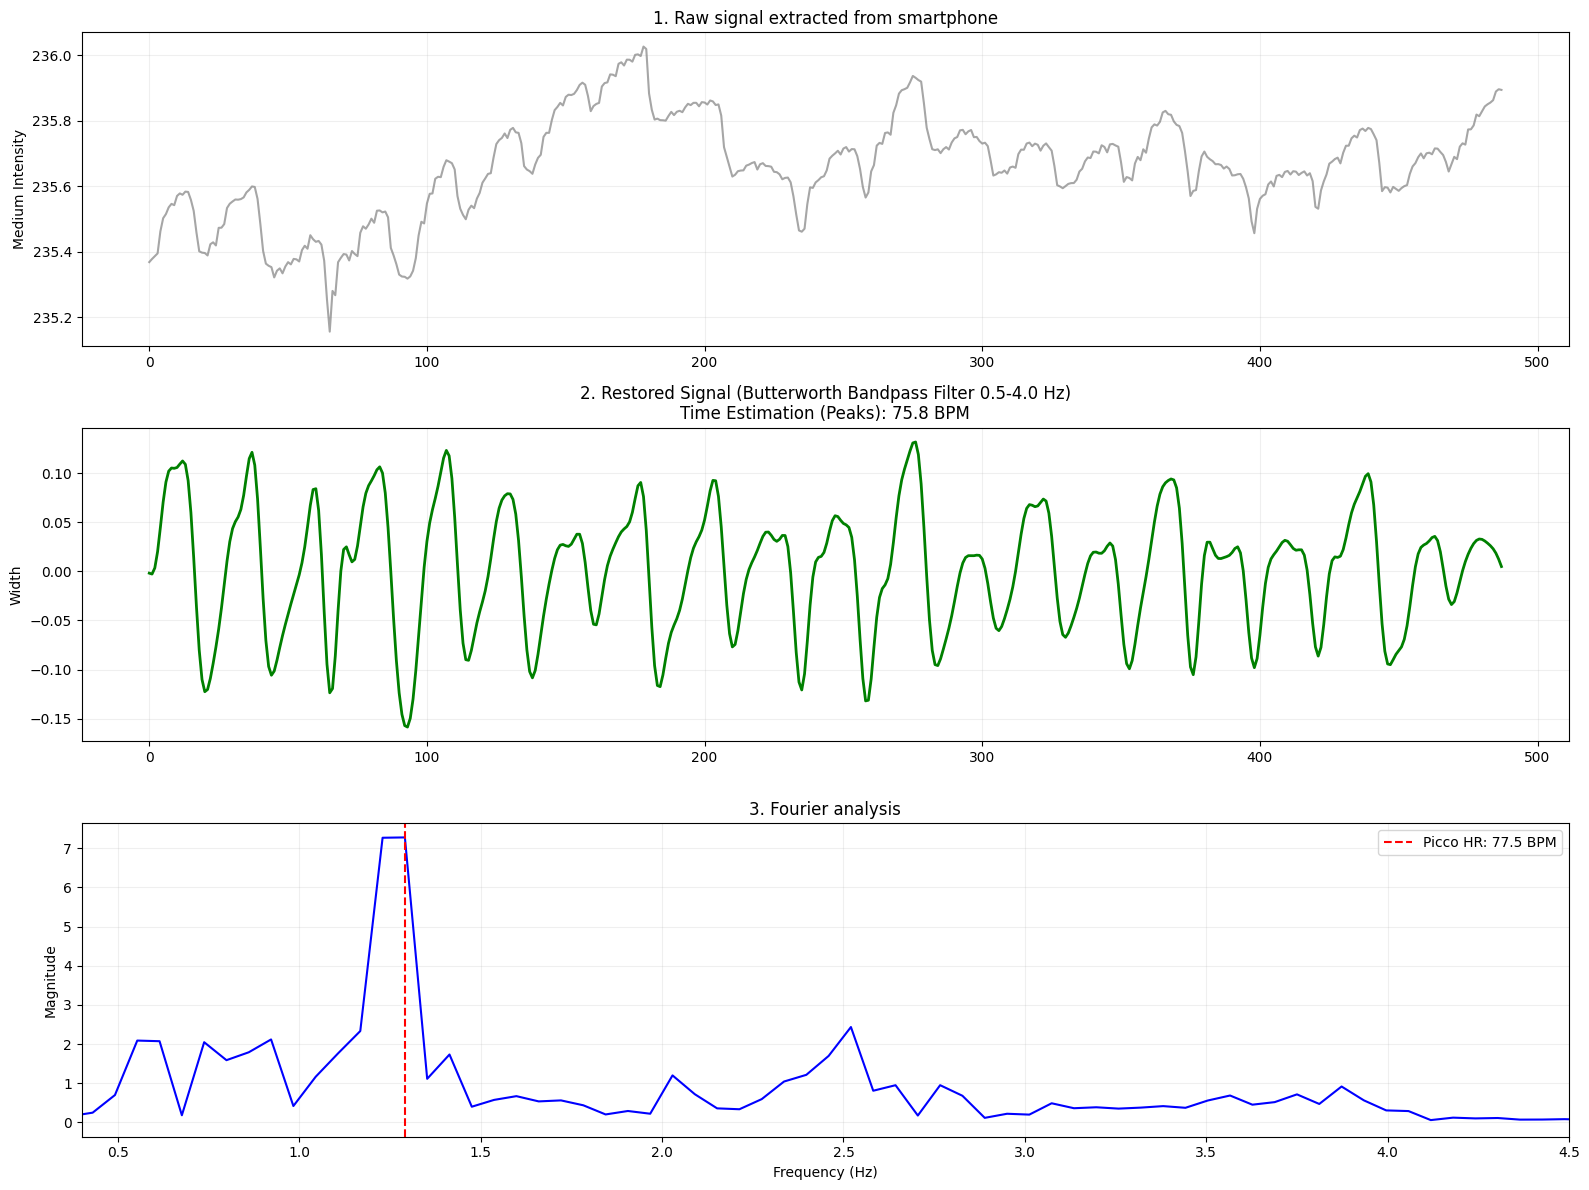

In [25]:
plt.figure(figsize=(16, 12))

# 1. Original raw signal
plt.subplot(3, 1, 1)
plt.plot(processed_signal, color='gray', alpha=0.7)
plt.title("1. Raw signal extracted from smartphone")
plt.ylabel("Medium Intensity")
plt.grid(alpha=0.2)

# 2. Restored Sign
plt.subplot(3, 1, 2)
plt.plot(restored_signal, color='green', linewidth=2)
plt.title(f"2. Restored Signal (Butterworth Bandpass Filter {LOWCUT}-{HIGHCUT} Hz)\n"
          f"Time Estimation (Peaks): {bpm_peaks:.1f} BPM")
plt.ylabel("Width")
plt.grid(alpha=0.2)

# 3. Fourier analysis
plt.subplot(3, 1, 3)
sig_fft = restored_signal - np.mean(restored_signal)
fft_plot = np.abs(np.fft.rfft(sig_fft * np.hamming(len(sig_fft))))
freqs_plot = np.fft.rfftfreq(len(sig_fft), 1/FS_VIDEO)
plt.plot(freqs_plot, fft_plot, color='blue')
plt.axvline(x=bpm_fft/60, color='red', linestyle='--', label=f'Picco HR: {bpm_fft:.1f} BPM')
plt.xlim(0.4, 4.5)
plt.title("3. Fourier analysis")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [26]:
print("-" * 30)
print(f"Photoplethysmogram (PPG) results:")
print(f"BPM FFT:   {bpm_fft:.2f}")
print(f"BPM Peaks: {bpm_peaks:.2f}")
print("-" * 30)

------------------------------
Photoplethysmogram (PPG) results:
BPM FFT:   77.46
BPM Peaks: 75.83
------------------------------
